In [1]:
import numpy as np

input_data = np.load('initial_data/function_6/initial_inputs.npy')
print("Before:", input_data.shape)
new_point = np.array([
    [0.435568, 0.234968, 0.819048, 0.903328, 0.039242],
    [0.259870, 0.046911, 0.220726, 0.903298, 0.022320],
    ])
input_data = np.vstack([input_data, new_point])
print("After:", input_data.shape)
print(input_data)


Before: (20, 5)
After: (22, 5)
[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.7049

In [2]:
output_data = np.load('initial_data/function_6/initial_outputs.npy')
print("Before:", output_data.shape)
new_output = np.array([
    -0.5489519703174699,
    -1.1254611667938943
    ])
output_data = np.append(output_data, new_output)
print("After:", output_data.shape)
print(output_data)


Before: (20,)
After: (22,)
[-0.71426495 -1.20995524 -1.67219994 -1.53605771 -0.82923655 -1.24704893
 -1.23378638 -1.69434344 -2.57116963 -1.30911635 -1.14478485 -1.91267714
 -1.62283895 -1.35668211 -2.0184254  -1.70255784 -1.29424696 -0.93575656
 -2.15576776 -1.74688209 -0.54895197 -1.12546117]


In [3]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [4]:
# Outputs span extreme ranges, so fit SVR in log|y| space
log_y = np.log(np.abs(output_data))

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(input_data)

print(f"log|y| range: [{log_y.min():.1f}, {log_y.max():.1f}]")
print(f"Negative outputs: {(output_data < 0).sum()} / {len(output_data)}")

log|y| range: [-0.6, 0.9]
Negative outputs: 22 / 22


In [5]:
svr = SVR(kernel='rbf', C=100.0, epsilon=0.5, gamma='scale')
svr.fit(X_scaled, log_y)

log_y_pred = svr.predict(X_scaled)
print(f"In-sample MSE (log space): {mean_squared_error(log_y, log_y_pred):.4f}")
print(f"In-sample R²  (log space): {r2_score(log_y, log_y_pred):.4f}")


In-sample MSE (log space): 0.0873
In-sample R²  (log space): 0.3289


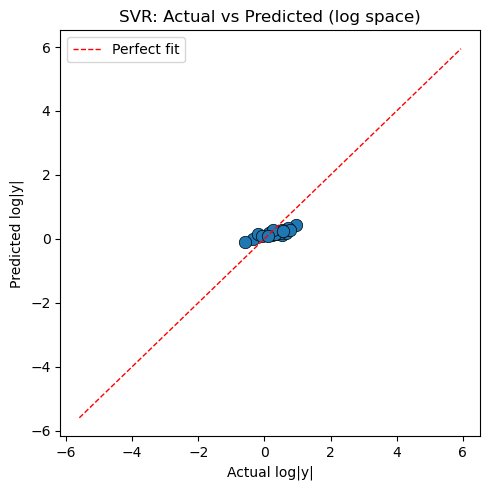

In [6]:
from scipy.stats import norm
plt.figure(figsize=(5, 5))
plt.scatter(log_y, log_y_pred, edgecolors='black', linewidths=0.5, s=80)
lims = [log_y.min() - 5, log_y.max() + 5]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
plt.xlabel('Actual log|y|')
plt.ylabel('Predicted log|y|')
plt.title('SVR: Actual vs Predicted (log space)')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
query = np.array([[0.5, 0.5, 0.5, 0.5, 0.5]])
log_pred = svr.predict(scaler_X.transform(query))[0]

actual_output = -0.994699779988161
actual_log    = np.log(np.abs(actual_output))

pred_output   = np.exp(log_pred)
abs_error     = np.abs(pred_output - actual_output)
rel_error     = abs_error / np.abs(actual_output) * 100

print(f"Query point:           {query[0]}")
print(f"Predicted log|output|: {log_pred:.4f}")
print(f"Actual    log|output|: {actual_log:.4f}")
print(f"Predicted |output|:    {pred_output:.4e}")
print(f"Actual    |output|:    {actual_output:.4e}")
print(f"Absolute error:        {abs_error:.4e}")
print(f"Relative error:        {rel_error:.2f}%")    

Query point:           [0.5 0.5 0.5 0.5 0.5]
Predicted log|output|: 0.1908
Actual    log|output|: -0.0053
Predicted |output|:    1.2103e+00
Actual    |output|:    -9.9470e-01
Absolute error:        2.2050e+00
Relative error:        221.67%
